In [23]:
import arviz as az
import numpy as np
from scipy.stats import wishart
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

Posterior to sample:

In [24]:
#def logprob_gaussian_10d(x):
#    logp = -0.5 * jnp.dot(x, x)
#    grad = -x
#    return logp, grad

# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 

grad_L = jax.grad(L)

Initialization:

In [25]:
theta0 = jnp.zeros(10)
key = jrnd.PRNGKey(0)

Warmup configuration:

In [26]:
warmup_cfg = WarmupConfig(
    num_warmup=1000,
    delta=0.8,
    adapt_mass=False,   
)


Run the algorithm:

In [27]:
samples, epsilon_final = nuts_sampler_alg6(
    theta0=theta0,
    num_warmup=1000,
    num_samples=1000,
    key=key,
    warmup_cfg=warmup_cfg,
    j_max=10
)

Check:

In [28]:
len(samples)

1000

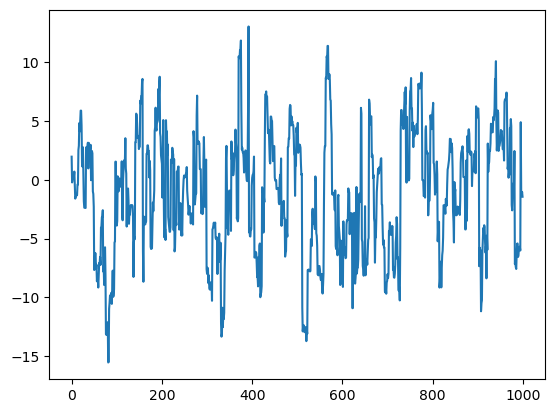

In [29]:
import matplotlib.pyplot as plt
plt.plot(samples[:,0])

In [30]:
print("Epsilon after the warmup:", epsilon_final)

Epsilon after the warmup: 0.22377434


In [31]:
print("mean:", samples.mean(axis=0))

mean: [-1.2056968   0.5264156   0.5641326   1.2085351   1.58753     2.776854
 -3.282027    0.83663964 -1.0678134   0.87180597]


In [32]:
print("std:", samples.std(axis=0))

std: [5.179714  1.7286204 1.6940451 2.356781  3.1413014 5.242424  5.9310946
 2.31586   2.8242753 3.0478237]


In [33]:
samples.shape

(1000, 10)

/home/pira/miniconda3/envs/inf/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

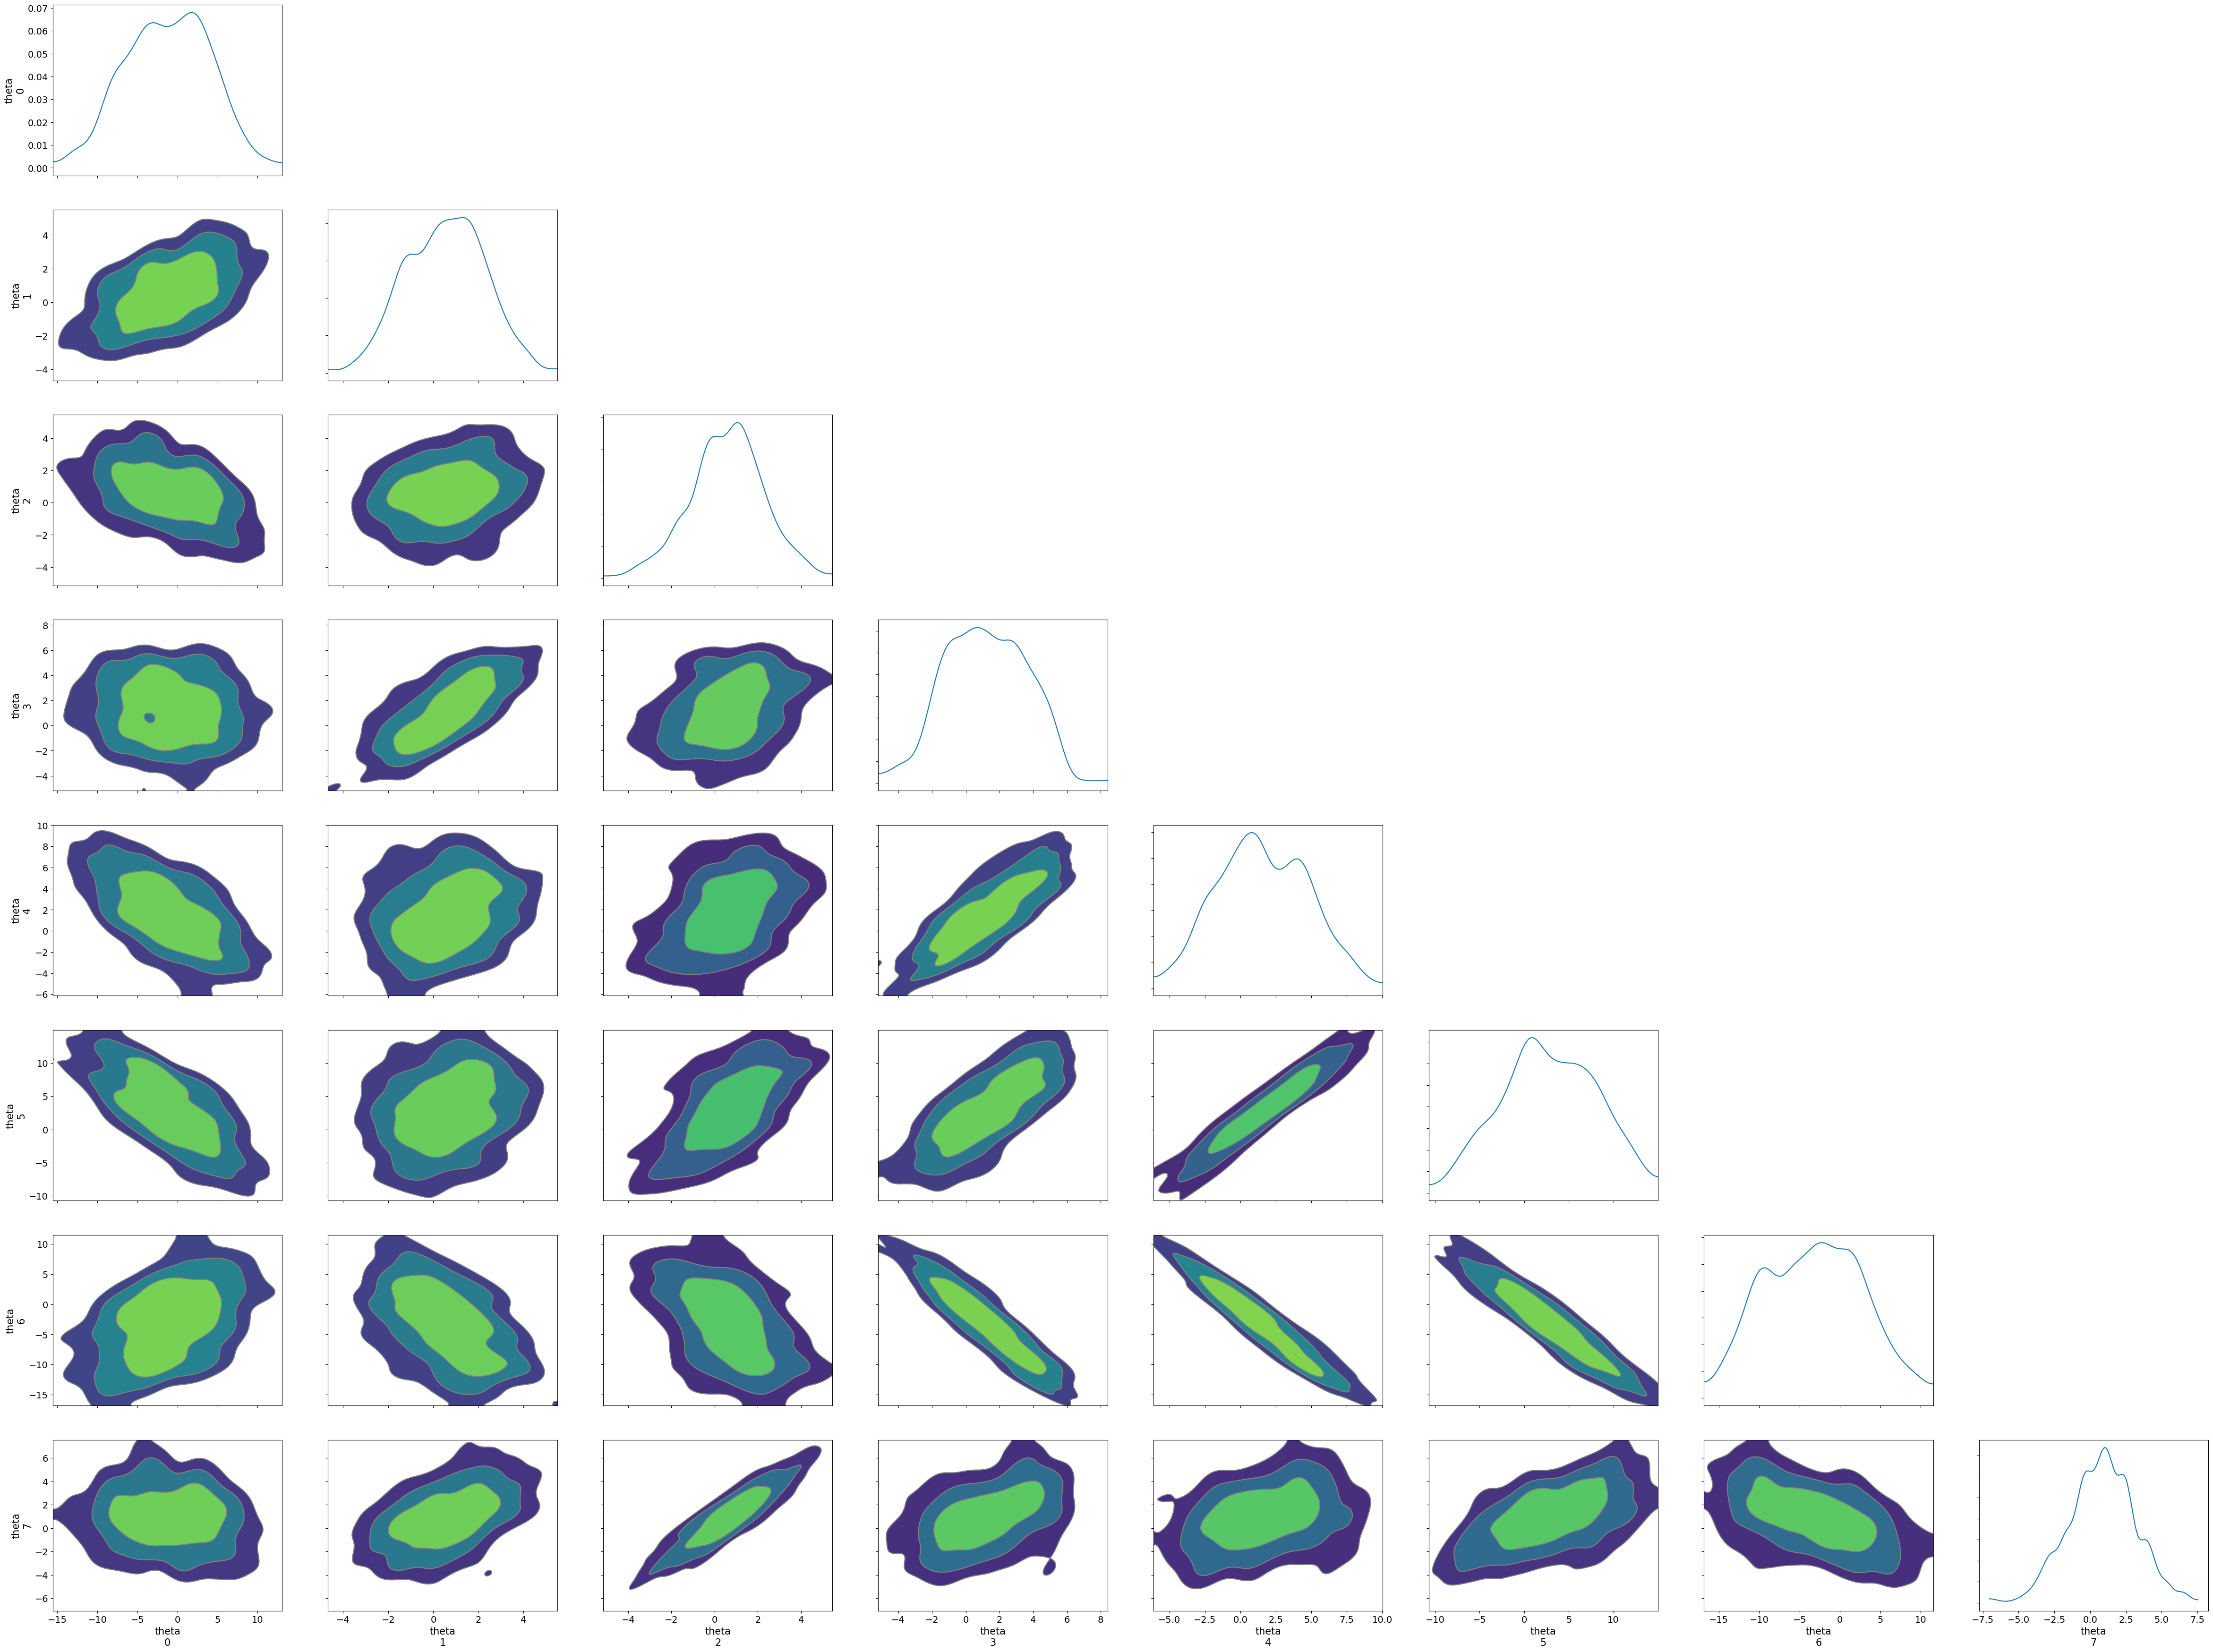

In [34]:
# add a pseudo dimension to plot the data
samples = samples[None, :, :]   # shape diventa (1, 1000, 10)

# plot the sampled data marginalized distributions
idata = az.from_dict(
    posterior={"theta": samples},
    coords={"theta_dim": np.arange(samples.shape[-1])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [35]:
# The theorical variance of each variable comes from inverting the precision matrix A
th_cov_mat = np.linalg.inv(A)
th_var_k = [ th_cov_mat[i,i] for i in range(D) ]
th_var_k

[np.float64(17.781220345391976),
 np.float64(1.9501961907725307),
 np.float64(2.5902294511420303),
 np.float64(4.015257292735635),
 np.float64(7.262011257769527),
 np.float64(23.04232321265636),
 np.float64(27.67829581962921),
 np.float64(5.0749694070982105),
 np.float64(5.946110118780801),
 np.float64(6.420260710626618)]

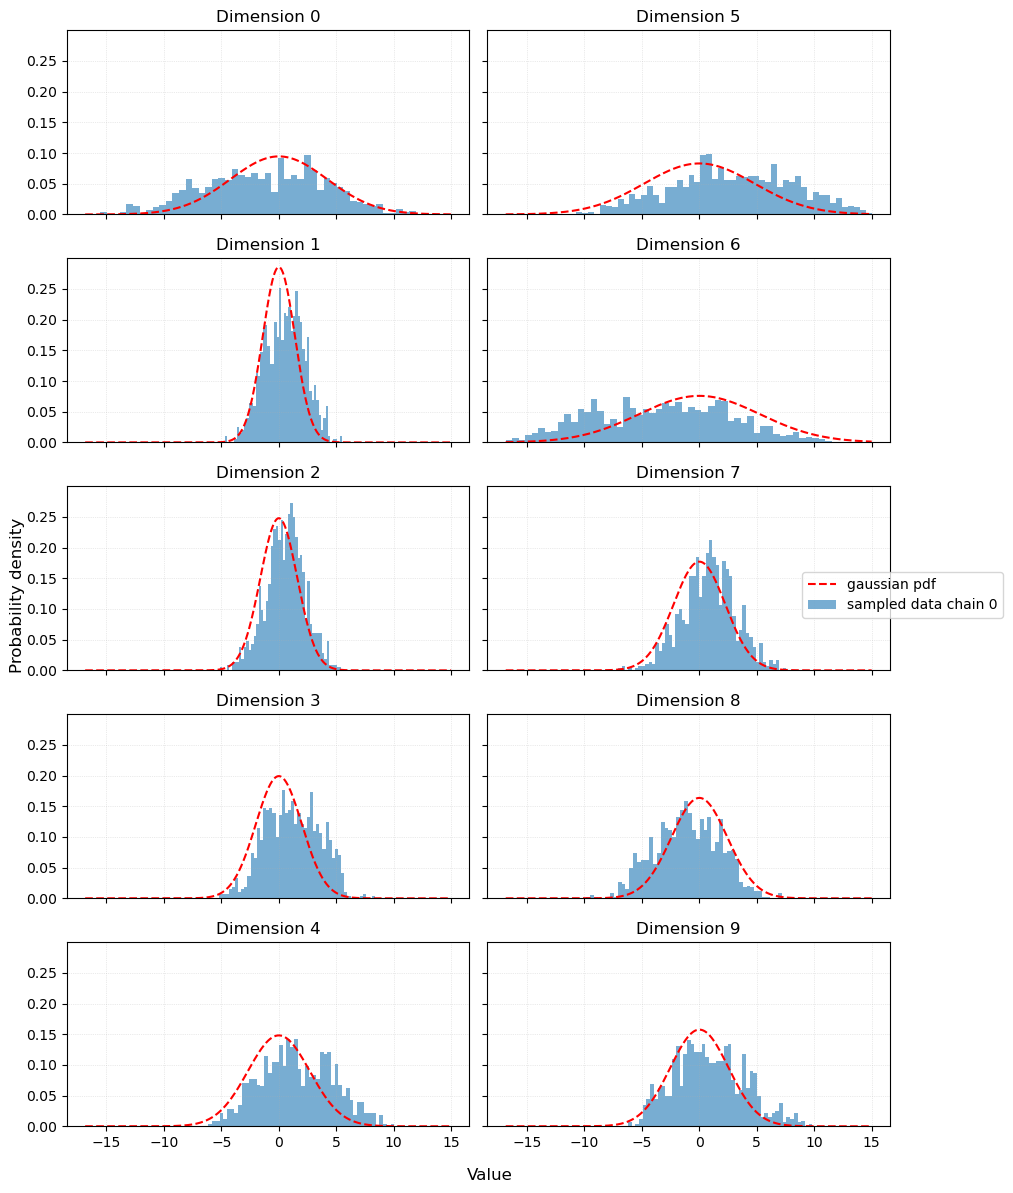

In [36]:
x = np.linspace(samples.min(), samples.max(), 1000)

fig, axs = plt.subplots(5, 2, figsize=(10, 12), sharex=True, sharey=True)

for j in range(2):        # colonne
    for i in range(5):    # righe
        
        k = i + 5*j       # indice globale della variabile (0..9)

        var = th_var_k[k]
        norm_factor = 1 / np.sqrt(2 * np.pi * var)
        pdf = norm_factor * np.exp(-(x**2) / (2 * var))

        axs[i, j].plot(x, pdf, color='red', label='gaussian pdf', linestyle= '--')
        axs[i, j].hist(samples[0,:, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 0')
        #axs[i, j].hist(samples_flat[2000:4000, k] , bins=50, density=True, alpha=0.6, label='sampled data chain 1')

        # add a grid
        axs[i, j].grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

        axs[i, j].set_title(f"Dimension {k}")

# --- LEGENDA UNICA ---
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

# --- ETICHETTE GLOBALI ---
fig.supxlabel("Value")
fig.supylabel("Probability density")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

In [37]:
# ESS della prima dimensione
ess_dim0 = ess_gelman(samples[0], lambda th: th[:, 0])
print(ess_dim0)

-10341154967.980019


In [38]:
x = samples[0][:, 0]
print(np.corrcoef(x[:-1], x[1:])[0,1])

0.883978766185696


In [39]:
acf = autocorr_functional(samples[0][:,0])
print(acf[:10])

[1.00000012 0.88469589 0.78723526 0.70256364 0.62551939 0.55173284
 0.48979074 0.43597829 0.38404971 0.34177029]


In [40]:
ess_dim0 = ess_gelman(samples[0], lambda th: th[:, 0])
print(ess_dim0)

-10341154967.980019
